# Cellpose so far failed on Taylors approach
because the cells that are been used have irregular shape and no clear cellmembranes -> cytoplasma is also fainting.\
also segmentation has to happen on puncta images.. 
https://www.mdpi.com/2313-433X/12/7/297?utm_source=copilot.com \
\
HoVer‑Net — handles weak boundaries
CellVit‑SAM — robust across modalities
Custom U‑Net with multi‑channel inputs (e.g., raw + enhanced cytoplasm)

In [19]:
from torch.utils.data import Dataset
import cv2
import torch
import numpy as np
import glob
import tifffile as tiff
import os
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

In [24]:
class CellDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, "*")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*")))

        # Build dictionary: base_name → mask_path
        self.mask_dict = {}
        for m in self.mask_paths:
            base = os.path.basename(m)
            base = base.replace("_masks", "")  # remove suffix
            self.mask_dict[base] = m

        # Filter images that have a matching mask
        self.pairs = []
        for img in self.img_paths:
            base = os.path.basename(img)
            if base in self.mask_dict:
                self.pairs.append((img, self.mask_dict[base]))
            else:
                print("⚠️ No mask found for:", base)

        print("Found", len(self.pairs), "image-mask pairs")

        if len(self.pairs) == 0:
            raise ValueError("No matching image-mask pairs found.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path).astype(np.float32)
        img = img / img.max()

        mask = tiff.imread(mask_path)
        mask = (mask > 0).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask


In [31]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(1, 64)
        self.d2 = DoubleConv(64, 128)
        self.d3 = DoubleConv(128, 256)
        self.d4 = DoubleConv(256, 512)

        self.u1 = DoubleConv(512 + 256, 256)
        self.u2 = DoubleConv(256 + 128, 128)
        self.u3 = DoubleConv(128 + 64, 64)

        self.maxpool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.maxpool(c1))
        c3 = self.d3(self.maxpool(c2))
        c4 = self.d4(self.maxpool(c3))

        u1 = self.up(c4)
        u1 = self.u1(torch.cat([u1, c3], dim=1))

        u2 = self.up(u1)
        u2 = self.u2(torch.cat([u2, c2], dim=1))

        u3 = self.up(u2)
        u3 = self.u3(torch.cat([u3, c1], dim=1))

        return torch.sigmoid(self.out(u3))


In [32]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


dataset = CellDataset("cellpose_training/Data", "cellpose_training/Mask")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

model = UNet().to(device).float()


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def dice_loss(pred, target):
    smooth = 1.
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - ((2. * intersection + smooth) /
                (pred.sum() + target.sum() + smooth))

for epoch in range(30):
    for img, mask in loader:
        img = img.to(device).float()
        mask = mask.to(device).float()

        pred = model(img)
        loss = criterion(pred, mask) + dice_loss(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}: {loss.item():.4f}")

    print(f"Epoch {epoch}: {loss.item():.4f}")


Found 69 image-mask pairs
Epoch 0: 1.2512
Epoch 0: 1.2512
Epoch 1: 1.2923
Epoch 1: 1.2923
Epoch 2: 1.2906
Epoch 2: 1.2906
Epoch 3: 1.2875
Epoch 3: 1.2875
Epoch 4: 1.2913
Epoch 4: 1.2913
Epoch 5: 1.2743
Epoch 5: 1.2743
Epoch 6: 1.2636
Epoch 6: 1.2636
Epoch 7: 1.2940
Epoch 7: 1.2940
Epoch 8: 1.2747
Epoch 8: 1.2747
Epoch 9: 1.2501
Epoch 9: 1.2501
Epoch 10: 1.2430
Epoch 10: 1.2430
Epoch 11: 1.2071
Epoch 11: 1.2071
Epoch 12: 1.3090
Epoch 12: 1.3090
Epoch 13: 1.2574
Epoch 13: 1.2574
Epoch 14: 7.4174
Epoch 14: 7.4174
Epoch 15: 1.2763
Epoch 15: 1.2763
Epoch 16: 1.0629
Epoch 16: 1.0629
Epoch 17: 1.4157
Epoch 17: 1.4157
Epoch 18: 1.0984
Epoch 18: 1.0984
Epoch 19: 1.0603
Epoch 19: 1.0603
Epoch 20: 1.1511
Epoch 20: 1.1511
Epoch 21: 1.0952
Epoch 21: 1.0952
Epoch 22: 2.0922
Epoch 22: 2.0922
Epoch 23: 0.9181
Epoch 23: 0.9181
Epoch 24: 1.2862
Epoch 24: 1.2862
Epoch 25: 1.1563
Epoch 25: 1.1563
Epoch 26: 1.1813
Epoch 26: 1.1813
Epoch 27: 0.7760
Epoch 27: 0.7760
Epoch 28: 1.4612
Epoch 28: 1.4612
Epoch 29

In [35]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.eval()
model.to(device)

with torch.no_grad():
    # Load TIFF safely
    img = tiff.imread("cellpose_training/20251210 3nM 540-D12_NEMO_TRAF6_HOIP-KO 1um_27mol/gfp_rollingball/gfp_rollingball_0136.tif")

    # Convert to float32
    img = img.astype(np.float32)

    # Normalize (important for TIFFs)
    img = img / img.max()

    # Convert to tensor
    img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    # Predict
    pred = model(img)[0,0].cpu().numpy()

    # Threshold
    mask = (pred > 0.5).astype(np.uint8) * 255

cv2.imwrite("prediction.png", mask)



True

In [ ]:
import tifffile as tiff
import numpy as np
import cv2

orig = tiff.imread("cellpose_training/20251210 3nM 540-D12_NEMO_TRAF6_HOIP-KO 1um_27mol/gfp_rollingball/gfp_rollingball_0136.tif").astype(np.float32)
orig = orig / orig.max()

mask = cv2.imread("prediction.png", 0).astype(np.float32) / 255

# Create overlay (green mask on grayscale image)
overlay = np.dstack([
    orig,                 # R channel
    orig * (1-mask) + mask,  # G channel (cells highlighted)
    orig                  # B channel
])

overlay = (overlay * 255).astype(np.uint8)

cv2.imwrite("overlay.png", overlay)


True

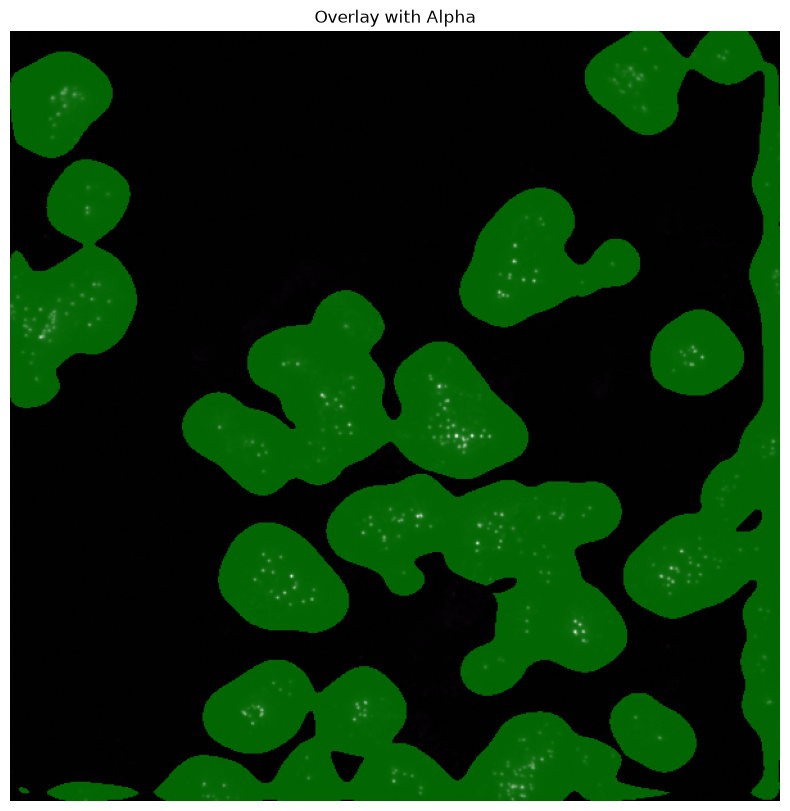

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff

# Load original TIFF
orig = tiff.imread("cellpose_training/20251210 3nM 540-D12_NEMO_TRAF6_HOIP-KO 1um_27mol/gfp_rollingball/gfp_rollingball_0136.tif").astype(np.float32)
orig = orig / orig.max()

# Load predicted mask (0–255)
mask = cv2.imread("prediction.png", 0).astype(np.float32)
mask = mask / 255.0

# Alpha value (transparency of mask)
alpha = 0.4  # adjust between 0 (invisible) and 1 (solid)

# Create overlay:
# - original image is grayscale
# - mask is shown in green with transparency
overlay = np.dstack([
    orig,                          # R channel
    orig * (1 - alpha) + mask * alpha,  # G channel (highlight)
    orig                           # B channel
])

# Plot
plt.figure(figsize=(10, 10))
plt.title("Overlay with Alpha")
plt.imshow(overlay)
plt.axis("off")
plt.show()
